In [1]:
!pip install huggingface

Load Dataset

In [2]:
from datasets import load_dataset

# Login using e.g. `huggingface-cli login` to access this dataset
ds = load_dataset("NYUGPUClass/NTT_dataset")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


ntt_benchmark_results_cuda2.csv: 0.00B [00:00, ?B/s]

ntt_benchmark_results_cuda3.csv: 0.00B [00:00, ?B/s]

ntt_benchmark_results_cuda4.csv: 0.00B [00:00, ?B/s]

ntt_benchmark_results_cuda5.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [ ]:
ds["train"]

Dataset({
    features: ['gpu_name', 'device_id', 'cc_major', 'cc_minor', 'sm_count', 'l2_size_bytes', 'shared_mem_per_sm', 'total_global_mem', 'mem_bandwidth_GBps_est', 'peak_flops_fp32_GFLOPs_est', 'driver_version', 'cuda_runtime_version', 'max_threads_per_sm', 'max_threads_per_block', 'warp_size', 'M', 'N', 'K', 'precision', 'repeats', 'inner_iters', 'algorithm', 'seed', 'tile_width', 'theoretical_occupancy', 'blocks_per_sm', 'grid_x', 'grid_y', 'block_x', 'block_y', 'registers_per_thread', 'shared_mem_per_block', 'time_ms_mean', 'time_ms_median', 'time_ms_p95', 'time_ms_stddev', 'gflops_mean', 'gflops_median', 'gflops_p95', 'actual_clock_mhz', 'actual_mem_clock_mhz', 'temperature_c', 'power_watts', 'ops_total', 'io_bytes_theoretical', 'gops_over_peak_mean', 'arithmetic_intensity_ops_per_byte', 'memory_throughput_GBps', 'memory_efficiency_pct', 'compute_efficiency_pct', 'peak_flops_fp32_GFLOPs_actual', 'compute_efficiency_actual_pct'],
    num_rows: 16020
})

# EDA

In [3]:
import pandas as pd

# Access the first (and likely only) split of the DatasetDict and convert to pandas DataFrame
df = ds["train"].to_pandas()

print("Dataset converted to pandas DataFrame.")

# Display general information about the DataFrame
df.info()

Dataset converted to pandas DataFrame.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   gpu_name                    10000 non-null  object 
 1   device_id                   10000 non-null  int64  
 2   cc_major                    10000 non-null  int64  
 3   cc_minor                    10000 non-null  int64  
 4   sm_count                    10000 non-null  int64  
 5   l2_size_bytes               10000 non-null  int64  
 6   shared_mem_per_sm           10000 non-null  int64  
 7   total_global_mem            10000 non-null  int64  
 8   mem_bandwidth_GBps_est      10000 non-null  float64
 9   peak_flops_fp32_GFLOPs_est  10000 non-null  float64
 10  driver_version              10000 non-null  int64  
 11  cuda_runtime_version        10000 non-null  int64  
 12  max_threads_per_sm          10000 non-null  int64 

## Show descriptive statistics


In [4]:
print("Descriptive statistics for numerical columns:")
df.describe()

Descriptive statistics for numerical columns:


,device_id,cc_major,cc_minor,sm_count,l2_size_bytes,shared_mem_per_sm,total_global_mem,mem_bandwidth_GBps_est,peak_flops_fp32_GFLOPs_est,driver_version,...,actual_clock_mhz,actual_mem_clock_mhz,temperature_c,power_watts,butterflies_total,modops_total,modops_per_sec,bytes_total_theoretical,memory_throughput_GBps,memory_efficiency_pct
count,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04,10000.000000,1.000000e+04,10000.000000,10000.000000,10000.0,...,10000.000000,10000.0000,10000.000000,10000.000000,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,10000.000000,10000.000000
mean,0.750000,6.750000,4.000000,54.500000,1.284506e+07,91136.000000,1.230656e+10,527.332000,19829.145500,13000.0,...,1679.571100,5226.2500,62.468400,135.537924,3.881743e+07,1.164523e+08,3.100035e+10,6.210789e+08,165.335188,30.354856
std,0.433034,1.089779,3.391335,21.419521,1.440910e+07,14875.202962,5.668136e+08,123.061897,9642.684019,0.0,...,622.852755,3599.3035,12.569662,57.673005,6.148642e+07,1.844593e+08,2.354575e+10,9.837828e+08,125.577339,19.205704
min,0.000000,5.000000,0.000000,24.000000,3.145728e+06,65536.000000,1.134762e+10,336.480000,8961.638000,13000.0,...,1202.000000,850.0000,32.000000,52.510000,2.457600e+05,7.372800e+05,8.341202e+07,3.932160e+06,0.445000,0.088000
25%,0.750000,6.500000,1.500000,40.500000,4.325376e+06,90112.000000,1.217446e+10,462.156000,15048.345500,13000.0,...,1333.250000,2465.5000,55.000000,89.005000,1.114112e+06,3.342336e+06,1.366771e+10,1.782579e+07,72.894000,16.193000
50%,1.000000,7.000000,3.500000,57.000000,5.242880e+06,98304.000000,1.254287e+10,560.024000,17478.144000,13000.0,...,1342.500000,4902.0000,59.000000,134.410000,4.980736e+06,1.494221e+07,2.424215e+10,7.969178e+07,129.291500,29.745000
75%,1.000000,7.250000,6.000000,71.000000,1.376256e+07,99328.000000,1.267497e+10,625.200000,22258.944000,13000.0,...,1695.000000,7662.7500,64.000000,162.395000,4.613734e+07,1.384120e+08,3.986948e+10,7.381975e+08,212.637000,38.387250
max,1.000000,8.000000,9.000000,80.000000,3.774874e+07,102400.000000,1.279289e+10,652.800000,35398.656000,13000.0,...,2760.000000,10251.0000,85.000000,261.750000,2.013266e+08,6.039798e+08,9.023226e+10,3.221225e+09,481.239000,73.719000


## Check for missing values

In [5]:
print("Missing values in each column:")
df_missing_values = df.isnull().sum()
print(df_missing_values)

Missing values in each column:
gpu_name                      0
device_id                     0
cc_major                      0
cc_minor                      0
sm_count                      0
l2_size_bytes                 0
shared_mem_per_sm             0
total_global_mem              0
mem_bandwidth_GBps_est        0
peak_flops_fp32_GFLOPs_est    0
driver_version                0
cuda_runtime_version          0
max_threads_per_sm            0
max_threads_per_block         0
warp_size                     0
N                             0
modulus                       0
primitive_root                0
repeats                       0
inner_iters                   0
algorithm                     0
seed                          0
time_ms_mean                  0
time_ms_median                0
time_ms_p95                   0
time_ms_stddev                0
actual_clock_mhz              0
actual_mem_clock_mhz          0
temperature_c                 0
power_watts                   0
butterfli

## Display first few rows

In [6]:
print("First 5 rows of the DataFrame:")
df.head()

First 5 rows of the DataFrame:


,gpu_name,device_id,cc_major,cc_minor,sm_count,l2_size_bytes,shared_mem_per_sm,total_global_mem,mem_bandwidth_GBps_est,peak_flops_fp32_GFLOPs_est,...,actual_clock_mhz,actual_mem_clock_mhz,temperature_c,power_watts,butterflies_total,modops_total,modops_per_sec,bytes_total_theoretical,memory_throughput_GBps,memory_efficiency_pct
0,NVIDIA GeForce RTX 2080 Ti,1,7,5,68,5767168,65536,11347623936,616.0,17077.248,...,1350,6800,52.0,153.20,10485760,31457280,8.225998e+10,167772160,438.720,71.221
1,NVIDIA GeForce RTX 2080 Ti,1,7,5,68,5767168,65536,11347623936,616.0,17077.248,...,1350,6800,53.0,136.16,46137344,138412032,3.793417e+10,738197504,202.316,32.843
2,NVIDIA GeForce RTX 2080 Ti,1,7,5,68,5767168,65536,11347623936,616.0,17077.248,...,1350,6800,52.0,111.13,4980736,14942208,7.385330e+10,79691776,393.884,63.942
3,NVIDIA GeForce RTX 2080 Ti,1,7,5,68,5767168,65536,11347623936,616.0,17077.248,...,1350,6800,53.0,136.73,46137344,138412032,3.793281e+10,738197504,202.308,32.842
4,NVIDIA GeForce RTX 2080 Ti,1,7,5,68,5767168,65536,11347623936,616.0,17077.248,...,1350,6800,54.0,141.26,22020096,66060288,5.020432e+10,352321536,267.756,43.467


## Explore unique values for categorical features

## Summary:

### Data Analysis Key Findings

*   The dataset contains 16020 entries and 52 columns.
*   The data types are distributed as follows: 22 columns are `float64`, 27 columns are `int64`, and 3 columns are `object`.
*   Several columns have a significant number of missing values (6010 out of 16020 entries), specifically: `seed`, `actual_clock_mhz`, `actual_mem_clock_mhz`, `temperature_c`, `power_watts`, `peak_flops_fp32_GFLOPs_actual`, and `compute_efficiency_actual_pct`.
*   Columns such as `device_id` and `driver_version` contain constant values across all records.
*   The dataset includes a wide range of GPU performance metrics and hardware specifications, such as `sm_count` (ranging from 24 to 80), `l2_size_bytes` (ranging from approximately 3.1 MB to 37.7 MB), and `peak_flops_fp32_GFLOPs_est` (ranging from 8961.6 to 35398.7 GFLOPs).

### Insights or Next Steps

*   Address the significant number of missing values in the identified columns. Strategies such as imputation, or careful consideration of whether these records are complete enough for certain analyses, will be necessary.
*   Investigate the columns with constant values (`device_id`, `driver_version`) to determine their relevance. If they are truly constant and not unique identifiers, they might be candidates for removal or require specific handling for modeling purposes.


# Data Cleaning

## Explore unique values for categorical features

We can drop `precision` and `algorithm` for now.


In [8]:
categorical_cols = ['gpu_name', 'algorithm']

for col in categorical_cols:
    print(f"Unique values for '{col}':")
    print(df[col].unique())
    print("\n")

Unique values for 'gpu_name':
['NVIDIA GeForce RTX 2080 Ti' 'NVIDIA TITAN V'
 'NVIDIA GeForce GTX TITAN X' 'NVIDIA GeForce RTX 4070']


Unique values for 'algorithm':
['Custom-NTT']




## Separate features and target variable

We will try to predict `time_ms_mean`, the mean time it takes to complete the kernel on a device for a certain data size. We will drop categorical columns that are constant as well as other `time_ms_*` columns which leak data.

In [9]:
y = df['time_ms_mean']

columns_to_drop = [
    'device_id', # Constant column
    'driver_version', # Constant column
    'algorithm', # Constant categorical column
    'time_ms_mean','time_ms_median', 'time_ms_p95', 'time_ms_stddev', # Performance metrics leading to data leakage
]

X = df.drop(columns=columns_to_drop)

print("Features (X) and target (y) separated successfully.")
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Features (X) and target (y) separated successfully.
Shape of X: (10000, 29)
Shape of y: (10000,)


## Handle missing values in numerical columns


We impute missing values in numerical columns with their respective medians.


In [10]:
missing_numerical_cols = X.select_dtypes(include=['number']).columns[X.select_dtypes(include=['number']).isnull().any()].tolist()
print("Numerical columns in X with missing values:")
print(missing_numerical_cols)

Numerical columns in X with missing values:
[]


In [11]:
print("Imputing missing numerical values with median...")
for col in missing_numerical_cols:
    median_val = X[col].median()
    X[col] = X[col].fillna(median_val)
    print(f"Missing values in '{col}' after imputation: {X[col].isnull().sum()}")

print("Missing values in numerical columns after imputation:")
print(X[missing_numerical_cols].isnull().sum())

Imputing missing numerical values with median...
Missing values in numerical columns after imputation:
Series([], dtype: float64)


## Encode categorical features

### Subtask:
Encode categorical features in the DataFrame X using one-hot encoding.


In [12]:
categorical_cols_to_encode = X.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns in X to be encoded:")
print(categorical_cols_to_encode)

Categorical columns in X to be encoded:
['gpu_name']


Now that the categorical columns have been identified, apply one-hot encoding to them using `pd.get_dummies()`, ensuring the original columns are dropped and the result is stored back into `X`.



In [13]:
print("Applying one-hot encoding to categorical features...")
X = pd.get_dummies(X, columns=categorical_cols_to_encode, drop_first=True)

print("Categorical features encoded successfully. First 5 rows of updated X:")
print(X.head())

Applying one-hot encoding to categorical features...
Categorical features encoded successfully. First 5 rows of updated X:
   cc_major  cc_minor  sm_count  l2_size_bytes  shared_mem_per_sm  \
0         7         5        68        5767168              65536   
1         7         5        68        5767168              65536   
2         7         5        68        5767168              65536   
3         7         5        68        5767168              65536   
4         7         5        68        5767168              65536   

   total_global_mem  mem_bandwidth_GBps_est  peak_flops_fp32_GFLOPs_est  \
0       11347623936                   616.0                   17077.248   
1       11347623936                   616.0                   17077.248   
2       11347623936                   616.0                   17077.248   
3       11347623936                   616.0                   17077.248   
4       11347623936                   616.0                   17077.248   

   cuda_run

## Scale numerical features

Scale numerical features in the DataFrame X to ensure they contribute equally to the model.  To scale numerical features, first identify all numerical columns in the DataFrame `X`, excluding any boolean columns that might have resulted from one-hot encoding. This ensures that only continuous numerical data is subjected to scaling.


In [14]:
numerical_cols_to_scale = X.select_dtypes(include=['number']).columns.tolist()
# Exclude boolean columns from scaling (these typically come from one-hot encoding)
# A boolean column in pandas is often represented as uint8 or bool dtype.
# We check for columns that are not already boolean dtypes
# and are not boolean in nature (i.e., not just 0s and 1s and only two unique values).

# Let's refine the identification of non-boolean numerical columns
non_boolean_numerical_cols = []
for col in numerical_cols_to_scale:
    # Check if the column is not already a boolean dtype
    # and if it has more than 2 unique values (to exclude one-hot encoded binary features if any were inadvertently included)
    # or if it has only two unique values, but they are not 0 and 1 (or True/False)
    if (X[col].dtype != 'bool') and (X[col].nunique() > 2 or not set(X[col].unique()).issubset({0, 1})):
        non_boolean_numerical_cols.append(col)

print("Numerical columns to scale:")
print(non_boolean_numerical_cols)

Numerical columns to scale:
['cc_major', 'cc_minor', 'sm_count', 'l2_size_bytes', 'shared_mem_per_sm', 'total_global_mem', 'mem_bandwidth_GBps_est', 'peak_flops_fp32_GFLOPs_est', 'cuda_runtime_version', 'max_threads_per_sm', 'max_threads_per_block', 'warp_size', 'N', 'modulus', 'primitive_root', 'repeats', 'inner_iters', 'seed', 'actual_clock_mhz', 'actual_mem_clock_mhz', 'temperature_c', 'power_watts', 'butterflies_total', 'modops_total', 'modops_per_sec', 'bytes_total_theoretical', 'memory_throughput_GBps', 'memory_efficiency_pct']


In [15]:
from sklearn.preprocessing import StandardScaler

print("Scaling numerical features using StandardScaler...")

# Instantiate the StandardScaler
scaler = StandardScaler()

# Fit and transform the identified numerical columns
X[non_boolean_numerical_cols] = scaler.fit_transform(X[non_boolean_numerical_cols])

print("Numerical features scaled successfully. First 5 rows of updated X:")
print(X.head())

Scaling numerical features using StandardScaler...
Numerical features scaled successfully. First 5 rows of updated X:
   cc_major  cc_minor  sm_count  l2_size_bytes  shared_mem_per_sm  \
0  0.229416  0.294884  0.630298      -0.491234          -1.721071   
1  0.229416  0.294884  0.630298      -0.491234          -1.721071   
2  0.229416  0.294884  0.630298      -0.491234          -1.721071   
3  0.229416  0.294884  0.630298      -0.491234          -1.721071   
4  0.229416  0.294884  0.630298      -0.491234          -1.721071   

   total_global_mem  mem_bandwidth_GBps_est  peak_flops_fp32_GFLOPs_est  \
0         -1.691891                0.720551                   -0.285401   
1         -1.691891                0.720551                   -0.285401   
2         -1.691891                0.720551                   -0.285401   
3         -1.691891                0.720551                   -0.285401   
4         -1.691891                0.720551                   -0.285401   

   cuda_runtime_

## Prepare for Model Training

Define the XGBoost Regressor and set up a parameter grid for hyperparameter tuning.  We will tune `n_estimators`,`learning_rate`, `max_depth`, `subsample`, and `colsample_bytree` with standard ranges.


In [16]:
from xgboost import XGBRegressor

# 1. Define an instance of XGBRegressor
xgb_model = XGBRegressor(random_state=42)

# 2. Define a dictionary named param_grid for hyperparameter tuning
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8],
    'colsample_bytree': [0.7, 0.8]
}

print("XGBoost Regressor model initialized and parameter grid defined.")

XGBoost Regressor model initialized and parameter grid defined.


## Model Training and Tuning

Split the data into training and testing sets, then perform hyperparameter tuning using GridSearchCV with cross-validation to find the best XGBoost model.


In [17]:
from sklearn.model_selection import train_test_split, GridSearchCV

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets successfully.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Instantiate GridSearchCV
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid,
                           scoring='neg_mean_squared_error', cv=3, verbose=1)

print("Starting GridSearchCV fit...")
grid_search.fit(X_train, y_train)
print("GridSearchCV fit complete.")

Data split into training and testing sets successfully.
X_train shape: (8000, 31)
X_test shape: (2000, 31)
y_train shape: (8000,)
y_test shape: (2000,)
Starting GridSearchCV fit...
Fitting 3 folds for each of 72 candidates, totalling 216 fits
GridSearchCV fit complete.


We can examine the best perfoming model in our grid search.  The negative MSE is -0.35455 which is reasonable given the statistics of the target variable.


In [18]:
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation score (negative mean squared error): ", grid_search.best_score_)


Best parameters found:  {'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Best cross-validation score (negative mean squared error):  -1.0653046878164096


In [19]:
print(f"max: {y.max()}, min: {y.min()}, mean:{y.mean()}")

max: 103.85912, min: 0.053903, mean:5.2863890171


## Model Evaluation


Next we evaluate the performance of the best XGBoost model on the test set using appropriate regression metrics.


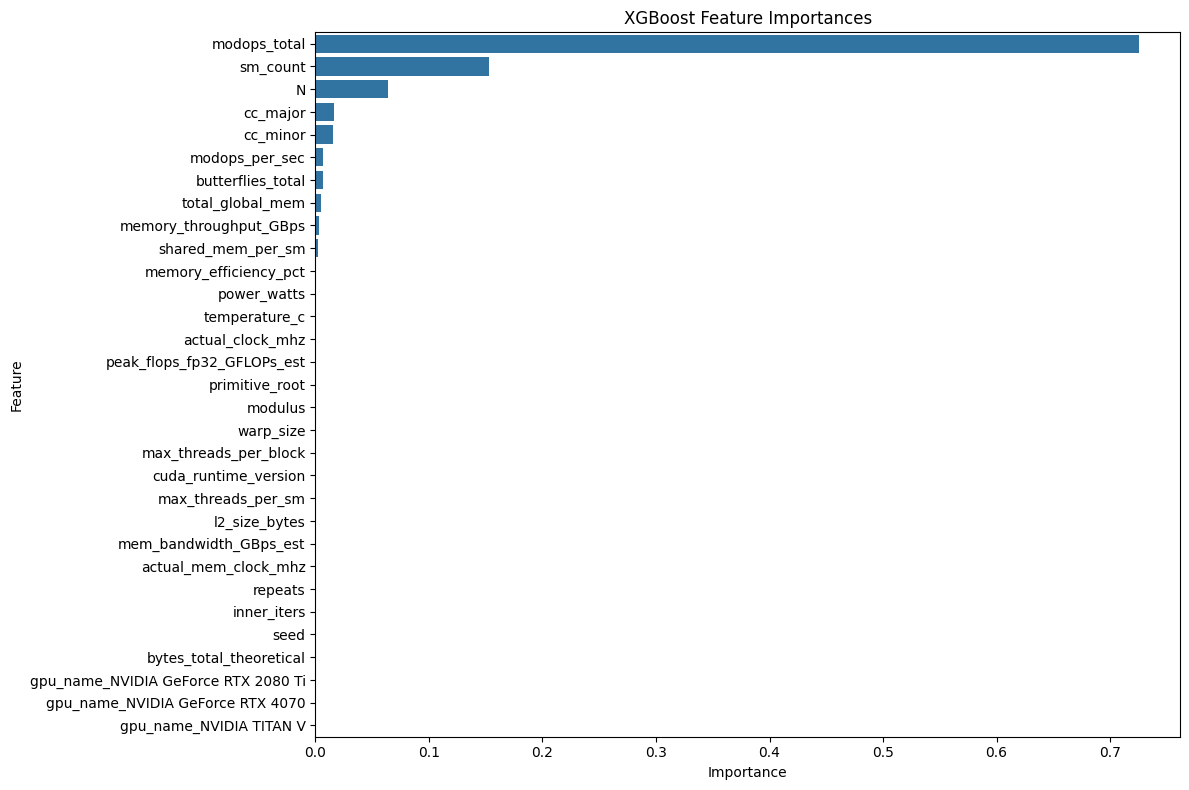

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the best estimator from GridSearchCV
best_xgb_model = grid_search.best_estimator_

# Get feature importances
feature_importances = best_xgb_model.feature_importances_

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances
})

# Sort features by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('XGBoost Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


# Check Performance on Test dataset and Upload Model to Hugging Face

In [21]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Get the best estimator from GridSearchCV
best_xgb_model = grid_search.best_estimator_

# Make predictions on the test set
y_pred = best_xgb_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) # Calculate RMSE by taking the square root of MSE
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation on Test Set:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R-squared (R2): {r2:.4f}")

Model Evaluation on Test Set:
Mean Squared Error (MSE): 0.0080
Root Mean Squared Error (RMSE): 0.0896
Mean Absolute Error (MAE): 0.0193
R-squared (R2): 0.9999


In [22]:
print("Please follow the prompts to log in to Hugging Face. You will be asked for your Hugging Face token.")
!huggingface-cli login

Please follow the prompts to log in to Hugging Face. You will be asked for your Hugging Face token.
⚠️  Warning: 'huggingface-cli login' is deprecated. Use 'hf auth login' instead.

    _|    _|  _|    _|    _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|_|_|_|    _|_|      _|_|_|  _|_|_|_|
    _|    _|  _|    _|  _|        _|          _|    _|_|    _|  _|            _|        _|    _|  _|        _|
    _|_|_|_|  _|    _|  _|  _|_|  _|  _|_|    _|    _|  _|  _|  _|  _|_|      _|_|_|    _|_|_|_|  _|        _|_|_|
    _|    _|  _|    _|  _|    _|  _|    _|    _|    _|    _|_|  _|    _|      _|        _|    _|  _|        _|
    _|    _|    _|_|      _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|        _|    _|    _|_|_|  _|_|_|_|

    To log in, `huggingface_hub` requires a token generated from https://huggingface.co/settings/tokens .
Enter your token (input will not be visible): 
Add token as git credential? (Y/n) y
Token is valid (permission: write).
The token `everythin

In [23]:
import joblib
from huggingface_hub import HfApi, create_repo, upload_file
import os

# Get the best estimator from GridSearchCV
best_xgb_model = grid_search.best_estimator_

# Define the path to save the model locally
model_filename = 'xgboost_gpu_perf_predictor_model.joblib'
local_model_path = f'./{model_filename}'

# Save the model locally
joblib.dump(best_xgb_model, local_model_path)
print(f"Model saved locally at: {local_model_path}")

# Define Hugging Face repository details
repo_id = "NYUGPUClass/gpu-perf-predictor-xgboost-tnn"

# Initialize Hugging Face API
api = HfApi()

try:
    # Create a new repository on Hugging Face Hub (private=False for public access)
    # Set exist_ok=True to avoid error if repo already exists
    create_repo(repo_id=repo_id, private=False, exist_ok=True)
    print(f"Repository '{repo_id}' created or already exists.")

    # Upload the saved model file to the repository
    upload_file(
        path_or_fileobj=local_model_path,
        path_in_repo=model_filename,
        repo_id=repo_id,
        repo_type="model",
    )
    print(f"Model '{model_filename}' uploaded to {repo_id}.")

    # Optionally, delete the local model file after upload
    os.remove(local_model_path)
    print(f"Local model file '{local_model_path}' removed.")

except Exception as e:
    print(f"Error uploading model to Hugging Face Hub: {e}")



Model saved locally at: ./xgboost_gpu_perf_predictor_model.joblib
Repository 'NYUGPUClass/gpu-perf-predictor-xgboost-tnn' created or already exists.


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...rf_predictor_model.joblib: 100%|##########|  233kB /  233kB            

  ...rf_predictor_model.joblib: 100%|##########|  233kB /  233kB            

Model 'xgboost_gpu_perf_predictor_model.joblib' uploaded to NYUGPUClass/gpu-perf-predictor-xgboost-tnn.
Local model file './xgboost_gpu_perf_predictor_model.joblib' removed.


# Alternative Modeling: SVM

We will repeat the training process using an SVM regression model.  We define a grid search using standard ranges for common tuning parameters `C`, `epsilon`, and `gamma`.

In [24]:
from sklearn.svm import SVR

# 1. Define an instance of SVR
# SVR does not have a random_state parameter, so we will omit it.
svr_model = SVR()

# 2. Define a dictionary named param_grid for hyperparameter tuning
param_grid = {
    'C': [0.1, 1, 10],
    'epsilon': [0.01, 0.1, 0.2],
    'gamma': ['scale', 'auto', 0.1, 1]
}

print("SVR model initialized and parameter grid defined.")

SVR model initialized and parameter grid defined.


In [26]:
from sklearn.model_selection import GridSearchCV

# Instantiate GridSearchCV for SVR
grid_search_svr = GridSearchCV(estimator=svr_model, param_grid=param_grid,
                           scoring='neg_mean_squared_error', cv=3, verbose=1)

print("Starting GridSearchCV fit for SVR model...")
grid_search_svr.fit(X_train, y_train)
print("GridSearchCV fit for SVR model complete.")

Starting GridSearchCV fit for SVR model...
Fitting 3 folds for each of 36 candidates, totalling 108 fits
GridSearchCV fit for SVR model complete.


**Reasoning**:
To conclude the hyperparameter tuning process for the SVR model, I will display the best parameters and the best cross-validation score found by `GridSearchCV`.



In [27]:
print("Best parameters for SVR found: ", grid_search_svr.best_params_)
print("Best cross-validation score (negative mean squared error) for SVR: ", grid_search_svr.best_score_)

Best parameters for SVR found:  {'C': 10, 'epsilon': 0.01, 'gamma': 0.1}
Best cross-validation score (negative mean squared error) for SVR:  -1.2613086486333496


## Model Evaluation (SVM)

Evaluate the performance of the best SVR model on the test set using appropriate regression metrics.


In [28]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Get the best estimator from GridSearchCV
best_svr_model = grid_search_svr.best_estimator_

# Make predictions on the test set
y_pred_svr = best_svr_model.predict(X_test)

# Evaluate the model
mse_svr = mean_squared_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mse_svr) # Calculate RMSE by taking the square root of MSE
mae_svr = mean_absolute_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)

print("SVR Model Evaluation on Test Set:")
print(f"Mean Squared Error (MSE): {mse_svr:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_svr:.4f}")
print(f"Mean Absolute Error (MAE): {mae_svr:.4f}")
print(f"R-squared (R2): {r2_svr:.4f}")

SVR Model Evaluation on Test Set:
Mean Squared Error (MSE): 0.0153
Root Mean Squared Error (RMSE): 0.1236
Mean Absolute Error (MAE): 0.0150
R-squared (R2): 0.9998


In [29]:
import joblib
from huggingface_hub import HfApi, create_repo, upload_file
import os

# Get the best estimator from GridSearchCV
best_svr_model = grid_search_svr.best_estimator_

# Define the path to save the model locally
model_filename = 'svr_gpu_perf_predictor_model.joblib'
local_model_path = f'./{model_filename}'

# Save the model locally
joblib.dump(best_svr_model, local_model_path)
print(f"Model saved locally at: {local_model_path}")

# Define Hugging Face repository details
repo_id = "NYUGPUClass/gpu-perf-predictor-svm-tnn"

# Initialize Hugging Face API
api = HfApi()

try:
    # Create a new repository on Hugging Face Hub (private=False for public access)
    # Set exist_ok=True to avoid error if repo already exists
    create_repo(repo_id=repo_id, private=False, exist_ok=True)
    print(f"Repository '{repo_id}' created or already exists.")

    # Upload the saved model file to the repository
    upload_file(
        path_or_fileobj=local_model_path,
        path_in_repo=model_filename,
        repo_id=repo_id,
        repo_type="model",
    )
    print(f"Model '{model_filename}' uploaded to {repo_id}.")

    # Optionally, delete the local model file after upload
    os.remove(local_model_path)
    print(f"Local model file '{local_model_path}' removed.")

except Exception as e:
    print(f"Error uploading model to Hugging Face Hub: {e}")



Model saved locally at: ./svr_gpu_perf_predictor_model.joblib
Repository 'NYUGPUClass/gpu-perf-predictor-svm-tnn' created or already exists.


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...rf_predictor_model.joblib: 100%|##########|  456kB /  456kB            

Model 'svr_gpu_perf_predictor_model.joblib' uploaded to NYUGPUClass/gpu-perf-predictor-svm-tnn.
Local model file './svr_gpu_perf_predictor_model.joblib' removed.
